In [3]:
!pip install opencv-python tqdm scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 17.9 MB/s eta 0:00:00


In [5]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 865.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 50.3 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [2]:
import os
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, Concatenate
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm import tqdm

In [3]:
image_dir = "/content/drive/MyDrive/Dataset/"   # main folder

img_height = 128
img_width = 128
batch_size = 16
epochs = 20

In [5]:
def load_all_good_images(base_dir, img_size=(128,128)):
    images = []

    # Loop through all type folders
    for folder in os.listdir(base_dir):
        type_path = os.path.join(base_dir, folder)

        if os.path.isdir(type_path):
            good_path = os.path.join(type_path, "train", "good")

            if os.path.exists(good_path):
                print(f"Loading from: {good_path}")

                for img_file in tqdm(os.listdir(good_path), desc=f"{folder}"):
                    img_path = os.path.join(good_path, img_file)

                    img = cv2.imread(img_path)
                    if img is None:
                        continue

                    img = cv2.resize(img, img_size)
                    img = img.astype(np.float32) / 255.0

                    images.append(img)

    return np.array(images)

In [6]:
X = load_all_good_images(image_dir, img_size=(img_height, img_width))

print("Total images loaded:", X.shape)

Loading from: /content/drive/MyDrive/Dataset/type9cam2/train/good


type9cam2: 100%|██████████| 721/721 [00:19<00:00, 37.29it/s] 


Loading from: /content/drive/MyDrive/Dataset/type7cam2/train/good


type7cam2: 100%|██████████| 711/711 [00:27<00:00, 26.21it/s] 


Loading from: /content/drive/MyDrive/Dataset/type4cam2/train/good


...

Loading from: /content/drive/MyDrive/Dataset/type10cam2/train/good


type10cam2: 100%|██████████| 717/717 [00:19<00:00, 37.39it/s]


Loading from: /content/drive/MyDrive/Dataset/type1cam1/train/good


type1cam1: 100%|██████████| 272/272 [00:05<00:00, 52.14it/s] 


Total images loaded: (4391, 128, 128, 3)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_val = train_test_split(X, test_size=0.2, random_state=42)

np.random.shuffle(X_train)

In [8]:
from tensorflow.keras.layers import Add, Multiply, Activation
from tensorflow.keras.applications import VGG16

# ======================
# Residual Block
# ======================
def residual_block(x, filters):
    shortcut = x

    x = Conv2D(filters, 3, activation='relu', padding='same')(x)
    x = Conv2D(filters, 3, activation='relu', padding='same')(x)

    shortcut = Conv2D(filters, 1, padding='same')(shortcut)

    return Add()([x, shortcut])

# ======================
# Attention Gate
# ======================
def attention_gate(x, g, filters):
    theta_x = Conv2D(filters, 1, padding='same')(x)
    phi_g   = Conv2D(filters, 1, padding='same')(g)

    add = Add()([theta_x, phi_g])
    act = Activation('relu')(add)

    psi = Conv2D(1, 1, activation='sigmoid', padding='same')(act)

    return Multiply()([x, psi])

# ======================
# Improved U-Net
# ======================
def build_improved_unet(input_shape=(128, 128, 3)):
    inputs = Input(input_shape)

    # Encoder (Residual)
    c1 = residual_block(inputs, 32)
    p1 = MaxPooling2D()(c1)

    c2 = residual_block(p1, 64)
    p2 = MaxPooling2D()(c2)

    c3 = residual_block(p2, 128)
    p3 = MaxPooling2D()(c3)

    # Bottleneck
    b = residual_block(p3, 256)

    # Decoder (Attention + Residual)
    u1 = Conv2DTranspose(128, 2, strides=2, padding='same')(b)
    att1 = attention_gate(c3, u1, 128)
    u1 = Concatenate()([u1, att1])
    c4 = residual_block(u1, 128)

    u2 = Conv2DTranspose(64, 2, strides=2, padding='same')(c4)
    att2 = attention_gate(c2, u2, 64)
    u2 = Concatenate()([u2, att2])
    c5 = residual_block(u2, 64)

    u3 = Conv2DTranspose(32, 2, strides=2, padding='same')(c5)
    att3 = attention_gate(c1, u3, 32)
    u3 = Concatenate()([u3, att3])
    c6 = residual_block(u3, 32)

    outputs = Conv2D(3, 1, activation='sigmoid')(c6)

    return Model(inputs, outputs)

In [9]:
from tensorflow.keras.applications.vgg16 import preprocess_input
def ssim_loss(y_true, y_pred):
    return 1 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))

def combined_loss(y_true, y_pred):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    return mse + ssim_loss(y_true, y_pred)

# ======================
# Perceptual Loss
# ======================
vgg = VGG16(include_top=False, weights='imagenet', input_shape=(128,128,3))
vgg.trainable = False

def perceptual_loss(y_true, y_pred):
    y_true_vgg = vgg(preprocess_input(y_true * 255.0))
    y_pred_vgg = vgg(preprocess_input(y_pred * 255.0))
    return tf.reduce_mean(tf.square(y_true_vgg - y_pred_vgg))

def final_loss(y_true, y_pred):
    return combined_loss(y_true, y_pred) + 0.1 * perceptual_loss(y_true, y_pred)

model = build_improved_unet((img_height, img_width, 3))

model.compile(
    optimizer=Adam(1e-4),
    loss=final_loss
)

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │        128 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 128,  │          0 │ conv2d_1[0][0],   │
│                     │ 32)               │            │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ add[0][0]         │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_3[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │      2,112 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 64,    │          0 │ conv2d_4[0][0],   │
│                     │ 64)               │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ add_1[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │    147,584 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 32, 32,    │      8,320 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 32, 32,    │          0 │ conv2d_7[0][0],   │
│                     │ 128)              │            │ conv2d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ add_2[0][0]       │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │    295,168 │ max_pooling2d_2[

 Total params: 2,056,166 (7.84 MB)

 Trainable params: 2,056,166 (7.84 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=epochs,
    batch_size=batch_size
)

Epoch 1/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 127s 379ms/step - loss: 1.1105 - val_loss: 0.2979
Epoch 2/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 45s 204ms/step - loss: 0.1212 - val_loss: 0.0643
Epoch 3/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 45s 202ms/step - loss: 0.0519 - val_loss: 0.0409
Epoch 4/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 45s 204ms/step - loss: 0.0364 - val_loss: 0.0310
Epoch 5/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 45s 203ms/step - loss: 0.0287 - val_loss: 0.0257
Epoch 6/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 45s 203ms/step - loss: 0.0251 - val_loss: 0.0230
Epoch 7/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 45s 203ms/step - loss: 0.0218 - val_loss: 0.0203
Epoch 8/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 45s 203ms/step - loss: 0.0194 - val_loss: 0.0179
Epoch 9/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 45s 204ms/step - loss: 0.0171 - val_loss: 0.0165
Epoch 10/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 45s 203ms/step - loss: 0.0158 - val_loss: 0.0149
Epoch 11/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 45s 203ms/step - loss: 0.0146 - val_loss: 0.0147
Epoch 12/20
220/22

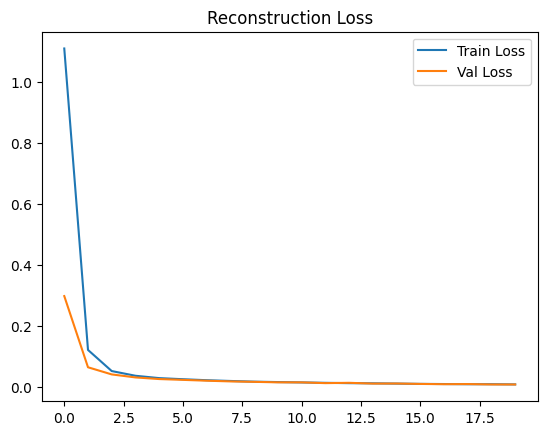

In [11]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Reconstruction Loss')
plt.legend()
plt.show()

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
from tensorflow.keras.models import load_model

model = load_model(
    "/content/drive/MyDrive/resunet_model.h5",
    custom_objects={
    "final_loss": final_loss,
    "ssim_loss": ssim_loss,
    "combined_loss": combined_loss
    }
)

In [13]:
val_errors = []

crop = 10   # ignore border pixels

# Iterate directly over the validation image data from X_val
# X_val already contains normalized images
for img_data_single in X_val[:100]:
    img_input = np.expand_dims(img_data_single, axis=0)

    recon = model.predict(img_input)[0]

    # ✅ Pixel-wise error
    error_map = np.mean((img_data_single - recon) ** 2, axis=2) # Compare original image data with reconstruction

    # ✅ Smooth error (reduce noise)
    error_map = cv2.GaussianBlur(error_map, (5,5), 0)

    # ✅ Remove borders
    h, w = error_map.shape
    cropped_error = error_map[crop:h-crop, crop:w-crop]

    # ✅ Top-K scoring (more robust)
    flat = cropped_error.flatten()
    score = np.mean(np.sort(flat)[-300:])   # top 300 pixels

    val_errors.append(score)

# ✅ Final threshold
threshold = np.mean(val_errors) + 2 * np.std(val_errors)

print("Threshold:", threshold)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━

Saving 3.png to 3.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


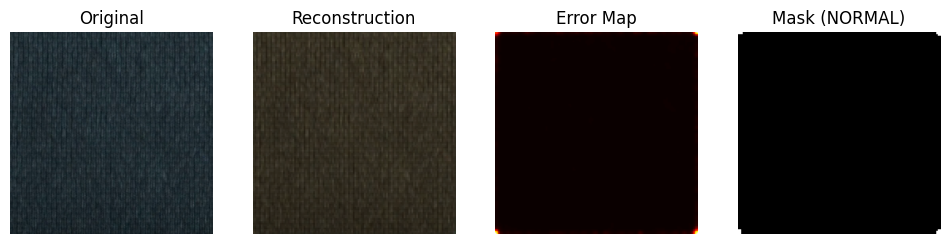

Score: 1.4618803148147566e-05
Prediction: NORMAL


In [16]:
from google.colab import files

uploaded = files.upload()

crop = 10   # ignore edges

for filename in uploaded.keys():
    img = cv2.imread(filename)
    original_size = img.shape[:2]

    img_resized = cv2.resize(img, (img_width, img_height))
    img_norm = img_resized / 255.0
    img_input = np.expand_dims(img_norm, axis=0)

    recon = model.predict(img_input)[0]

    # ✅ Pixel-wise MSE error
    error_map = np.mean((img_norm - recon) ** 2, axis=2)

    # ✅ Smooth error (removes texture noise)
    error_map = cv2.GaussianBlur(error_map, (5,5), 0)

    # ✅ Remove borders
    h, w = error_map.shape
    cropped_error = error_map[crop:h-crop, crop:w-crop]

    # ✅ Resize for visualization
    error_map_resized = cv2.resize(error_map, (original_size[1], original_size[0]))

    # ✅ Pixel threshold (ONLY on cropped region)
    #pixel_threshold = np.percentile(cropped_error, 99)

    # ✅ Mask creation

    # ✅ Normalize error map (0 → 1)
    norm_error = (error_map - error_map.min()) / (error_map.max() - error_map.min() + 1e-8)

    # ✅ Threshold based on intensity (like red region)
    pixel_threshold = 0.2   # you can tune: 0.3–0.6

    mask = (norm_error > pixel_threshold).astype(np.uint8) * 255
    # mask = np.zeros_like(error_map, dtype=np.uint8)
    # mask[crop:h-crop, crop:w-crop] = (cropped_error > pixel_threshold).astype(np.uint8)

    # ✅ Resize mask
    # mask = cv2.resize(mask, (original_size[1], original_size[0])) * 255

    # 🔥 Morphological cleaning
    kernel = np.ones((3,3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # ✅ Better scoring (Top-K on cropped region)
    flat = cropped_error.flatten()
    score = np.mean(np.sort(flat)[-5:])

    # ✅ Classification
    label = "ANOMALY" if score > threshold else "NORMAL"

    # 🔥 Normalize error map for display
    vis_error = (error_map - error_map.min()) / (error_map.max() - error_map.min() + 1e-8)

    # Plot
    plt.figure(figsize=(12,4))

    plt.subplot(1,4,1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.imshow(recon.astype(np.float32)) # Cast recon to float32
    plt.title("Reconstruction")
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.imshow(vis_error.astype(np.float32), cmap='hot') # Cast vis_error to float32
    plt.title("Error Map")
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.imshow(mask, cmap='gray')
    plt.title(f"Mask ({label})")
    plt.axis("off")

    plt.show()

    print("Score:", score)
    print("Prediction:", label)
